In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing(as_frame=True)
df = housing.frame


print(df.shape)
print(df.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [5]:
print(df.columns.tolist())
print("\nTarget variable:", housing.target_names)
print("\nMissing values:\n", df.isnull().sum())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Target variable: ['MedHouseVal']

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


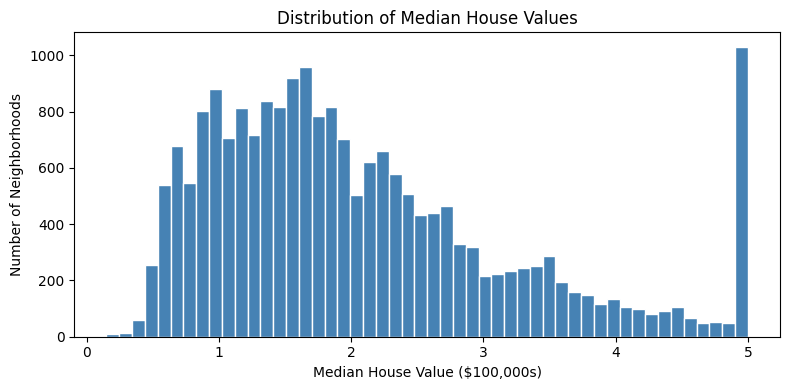

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Number of Neighborhoods')
plt.tight_layout()
plt.show()

In [12]:
# Separate features from target
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (16512, 8)
Test set:     (4128, 8)


In [13]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print("First row of scaled training data:")
print(X_train_scaled[0].round(2))

Scaling done!
First row of scaled training data:
[-0.33  0.35 -0.17 -0.21  0.77  0.05 -1.37  1.27]


In [14]:
# Create new features from existing ones
df_engineered = X.copy()

# Rooms per person - overcrowded neighborhoods = lower value
df_engineered['RoomsPerPerson'] = X['AveRooms'] / X['AveOccup']

# Bedrooms as a share of total rooms - higher ratio = less living space
df_engineered['BedroomRatio'] = X['AveBedrms'] / X['AveRooms']

# Population density proxy
df_engineered['PopulationPerRoom'] = X['Population'] / X['AveRooms']

print("New features added:")
print(df_engineered[['RoomsPerPerson', 'BedroomRatio', 'PopulationPerRoom']].describe().round(2))

New features added:
       RoomsPerPerson  BedroomRatio  PopulationPerRoom
count        20640.00      20640.00           20640.00
mean             1.98          0.21             287.89
std              1.15          0.06             247.14
min              0.00          0.10               0.21
25%              1.52          0.18             144.41
50%              1.94          0.20             225.25
75%              2.30          0.24             352.47
max             55.22          1.00            6770.14


In [15]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df_engineered, y, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

print(f"Engineered feature set shape: {X_train2_scaled.shape}")

Engineered feature set shape: (16512, 11)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train2_scaled, y_train2)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test2_scaled)

# Evaluate
rmse = root_mean_squared_error(y_test2, y_pred_lr)
r2 = r2_score(y_test2, y_pred_lr)

print(f"Linear Regression Results:")
print(f"  RMSE : {rmse:.4f}  (${rmse * 100_000:,.0f})")
print(f"  R²   : {r2:.4f}")

Linear Regression Results:
  RMSE : 0.6759  ($67,587)
  R²   : 0.6514


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train2_scaled, y_train2)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test2_scaled)

rmse_rf = root_mean_squared_error(y_test2, y_pred_rf)
r2_rf = r2_score(y_test2, y_pred_rf)

print(f"Random Forest Results:")
print(f"  RMSE : {rmse_rf:.4f}  (${rmse_rf * 100_000:,.0f})")
print(f"  R²   : {r2_rf:.4f}")

print(f"\nImprovement over Linear Regression:")
print(f"  RMSE improvement : ${(rmse - rmse_rf) * 100_000:,.0f} less error")
print(f"  R² improvement   : +{r2_rf - r2:.4f}")

Random Forest Results:
  RMSE : 0.5059  ($50,590)
  R²   : 0.8047

Improvement over Linear Regression:
  RMSE improvement : $16,997 less error
  R² improvement   : +0.1533


              Feature  Importance
0              MedInc      0.5209
5            AveOccup      0.1272
6            Latitude      0.0831
7           Longitude      0.0831
1            HouseAge      0.0516
9        BedroomRatio      0.0285
8      RoomsPerPerson      0.0254
2            AveRooms      0.0244
3           AveBedrms      0.0214
4          Population      0.0173
10  PopulationPerRoom      0.0171


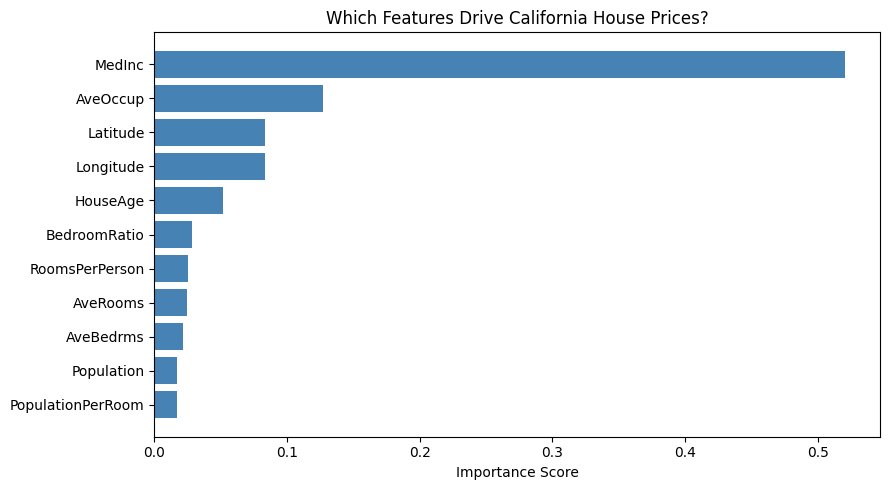

In [19]:
# Feature importance
feature_names = df_engineered.columns.tolist()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df.round(4))

# Plot it
plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Which Features Drive California House Prices?')
plt.tight_layout()
plt.show()

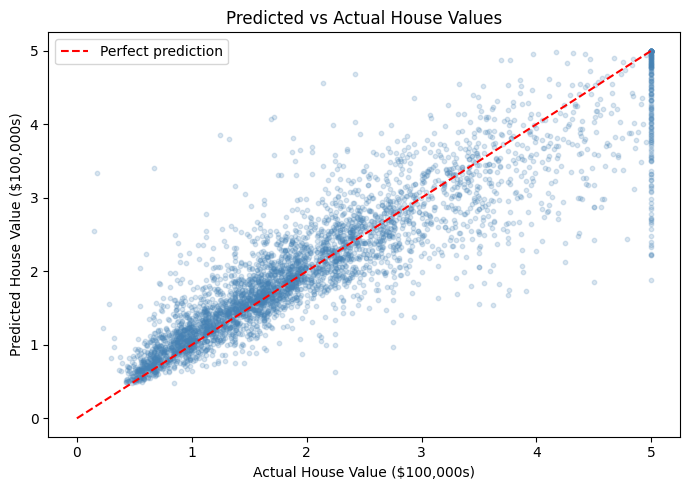

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test2, y_pred_rf, alpha=0.2, color='steelblue', s=10)
plt.plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual House Value ($100,000s)')
plt.ylabel('Predicted House Value ($100,000s)')
plt.title('Predicted vs Actual House Values')
plt.legend()
plt.tight_layout()
plt.show()